In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def compute_tangent_normal(x_func, y_func, t0, dt=1e-5):
    """
    Computes unit tangent and normal vectors for a parametric curve at t0.
    """
    # Numerical derivatives
    dx_dt = (x_func(t0 + dt) - x_func(t0 - dt)) / (2 * dt)
    dy_dt = (y_func(t0 + dt) - y_func(t0 - dt)) / (2 * dt)
    
    # Tangent vector
    tangent = np.array([dx_dt, dy_dt])
    tangent_norm = np.linalg.norm(tangent)
    
    if tangent_norm < 1e-10:
        return None, None, None
    
    tangent_unit = tangent / tangent_norm
    
    # Rotate tangent by +pi/2 to get normal (counterclockwise)
    normal_unit = np.array([-tangent_unit[1], tangent_unit[0]])
    
    # Point on the curve
    point = np.array([x_func(t0), y_func(t0)])
    
    return point, tangent_unit, normal_unit

def symmetry_set(x_func, y_func, tvals, lambda_max=50):
    """
    Compute symmetry set by detecting sign changes in the tangency condition.
    """
    centers = []
    threshold = 5 * (tvals[1] - tvals[0])
    
    for i, t1 in enumerate(tvals):
        result1 = compute_tangent_normal(x_func, y_func, t1)
        if result1[0] is None:
            continue
        p1, T1, N1 = result1
        
        # Store previous values for sign change detection
        prev_check1 = None
        prev_check2 = None
        prev_t2 = None
        
        for j, t2 in enumerate(tvals[i+1:], i+1):
            if abs(t2 - t1) < threshold:
                continue
            
            result2 = compute_tangent_normal(x_func, y_func, t2)
            if result2[0] is None:
                continue
            p2, T2, N2 = result2
            
            # Skip if tangents are parallel or anti-parallel
            if np.linalg.norm(T1-T2) < 1e-5 or np.linalg.norm(T1+T2) < 1e-5:
                prev_check1 = None
                prev_check2 = None
                continue
            
            # Compute tangency conditions
            eq_check1 = np.dot((p1-p2), (T1+T2))
            eq_check2 = np.dot((p1-p2), (T1-T2))
            
            # Check for sign changes
            if prev_check1 is not None:
                # Check if eq_check1 changed sign
                if prev_check1 * eq_check1 < 0:  # Sign change detected
                    # Interpolate to find better approximation of zero crossing
                    alpha = abs(prev_check1) / (abs(prev_check1) + abs(eq_check1))
                    t_interp = prev_t2 + alpha * (t2 - prev_t2)
                    
                    # Compute at interpolated point
                    p_interp, T_interp, N_interp = compute_tangent_normal(x_func, y_func, t_interp)
                    if p_interp is not None:
                        # Use the sum formula for center calculation
                        Nsum = N1 + N_interp
                        denom = np.dot(Nsum, Nsum)
                        if abs(denom) > 1e-8:
                            lam = np.dot(p_interp - p1, Nsum) / denom
                            if abs(lam) < lambda_max:
                                center = p1 + lam * N1
                                centers.append(center)
                
                # Check if eq_check2 changed sign
                if prev_check2 * eq_check2 < 0:  # Sign change detected
                    # Interpolate to find better approximation of zero crossing
                    alpha = abs(prev_check2) / (abs(prev_check2) + abs(eq_check2))
                    t_interp = prev_t2 + alpha * (t2 - prev_t2)
                    
                    # Compute at interpolated point
                    p_interp, T_interp, N_interp = compute_tangent_normal(x_func, y_func, t_interp)
                    if p_interp is not None:
                        # Use the difference formula for center calculation
                        Nsub = N1 - N_interp
                        denom = np.dot(Nsub, Nsub)
                        if abs(denom) > 1e-8:
                            lam = np.dot(p_interp - p1, Nsub) / denom
                            if abs(lam) < lambda_max:
                                center = p1 + lam * N1
                                centers.append(center)
            
            # Store current values for next iteration
            prev_check1 = eq_check1
            prev_check2 = eq_check2
            prev_t2 = t2
    
    return np.array(centers)

# Test with ellipse
a, b = 5, 3
x_func = lambda t: a * (2 * np.cos(t) - np.cos(2*t))
y_func = lambda t: a * (2 * np.sin(t) - np.sin(2*t))
t_vals = np.linspace(0, 2*np.pi, 500)

# Compute symmetry set
centers = symmetry_set(x_func, y_func, t_vals)

# Generate curve points
curve = np.array([np.array((x_func(t), y_func(t))) for t in t_vals])

# Plot
plt.figure(figsize=(10, 10))
plt.plot(curve[:,0], curve[:,1], 'b-', linewidth=2, label='Curve γ(t)')
if len(centers) > 0:
    plt.scatter(centers[:,0], centers[:,1], s=3, color='red', 
               alpha=0.6, label=f'Symmetry Set ({len(centers)} points)')
plt.axis('equal')
plt.legend()
plt.title("Symmetry Set")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True, alpha=0.3)
plt.show()

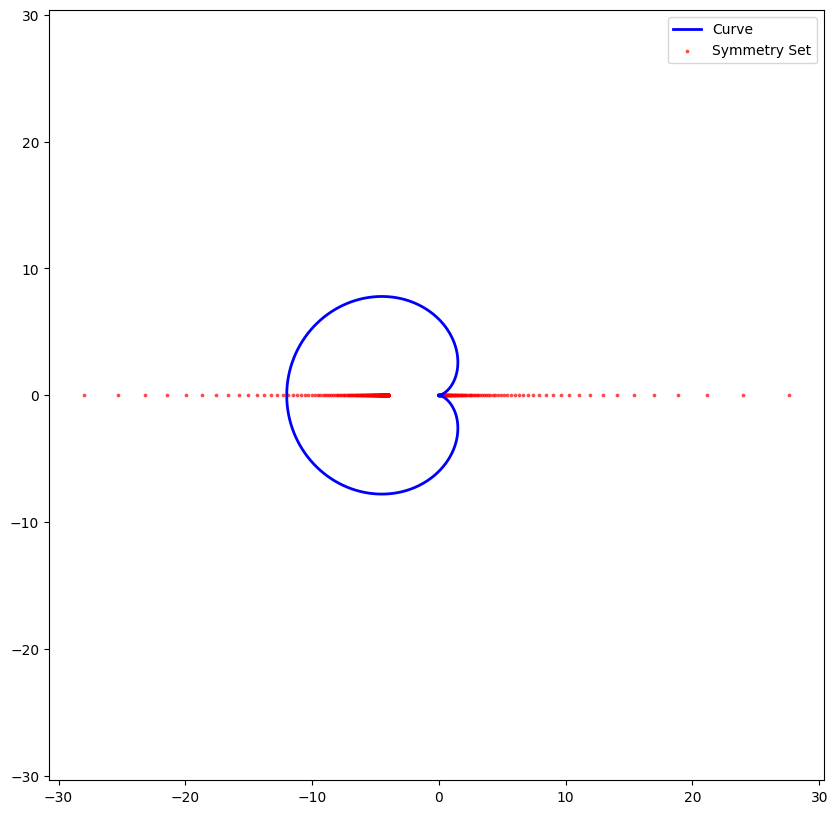

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('symmetry_set.csv')
curve = df[df['type'] == 'curve']
symmetry = df[df['type'] == 'symmetry']

plt.figure(figsize=(10, 10))
plt.plot(curve['x'], curve['y'], 'b-', linewidth=2, label='Curve')
plt.scatter(symmetry['x'], symmetry['y'], s=3, color='red', alpha=0.6, label='Symmetry Set')
plt.axis('equal')
plt.legend()
plt.show()

In [33]:
import numpy as np
import matplotlib.pyplot as plt

def plot_parametric_curve(x_func, y_func, t_min, t_max, num_points=500, color='b', linewidth=2, label='Parametric Curve'):
    """
    Plots a 2D parametric curve given x(t) and y(t).

    Parameters:
        x_func, y_func : callable
            Functions defining the parametric curve, i.e. x = x(t), y = y(t)
        t_min, t_max : float
            Range of the parameter t
        num_points : int, optional
            Number of sample points (default 500)
        color : str, optional
            Curve color (default 'b')
        linewidth : float, optional
            Width of the curve line (default 2)
        label : str, optional
            Legend label for the curve (default 'Parametric Curve')
    """
    # Generate parameter values
    t_vals = np.linspace(t_min, t_max, num_points)
    
    # Evaluate x(t), y(t)
    x_vals = x_func(t_vals)
    y_vals = y_func(t_vals)

    # Plot
    plt.figure(figsize=(7,7))
    plt.plot(x_vals, y_vals, color=color, linewidth=linewidth, label=label)
    plt.xlabel("x(t)")
    plt.ylabel("y(t)")
    plt.title("2D Parametric Curve")
    plt.axis('equal')
    plt.grid(True)
    plt.legend()
    plt.show()


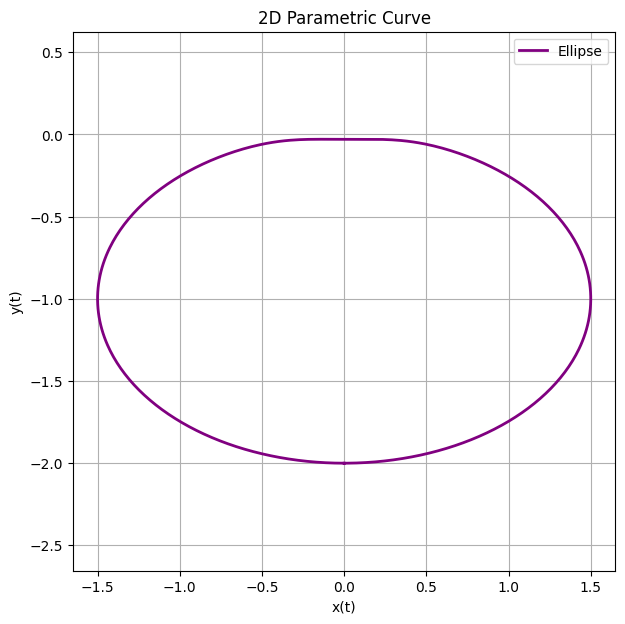

In [46]:
a, b = 1.5,1
H,q = 0.03,20
x_func = lambda t: a * np.sin(t)
y_func = lambda t: (b * (np.cos(t)-1)) - (H * np.exp(-np.longdouble(q)*(np.longdouble(t)**2)))

plot_parametric_curve(x_func, y_func, -np.pi,np.pi, color='purple', label='Ellipse')

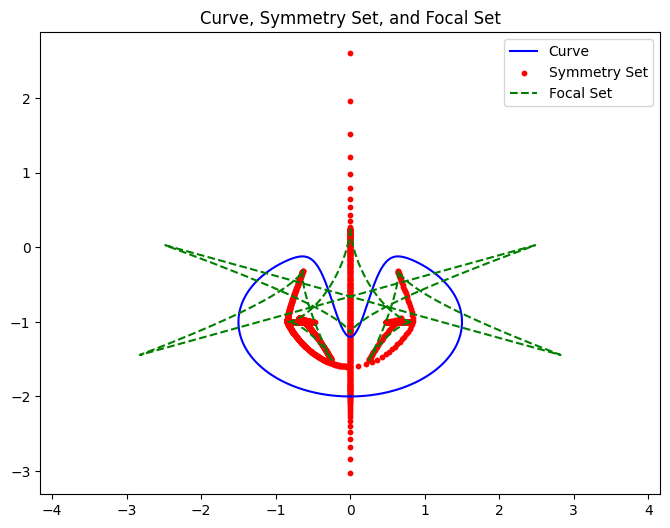

In [48]:
import pandas as pd
import matplotlib.pyplot as plt

# Load CSV
df = pd.read_csv("symmetry_focal_set.csv")

# Separate points
curve = df[df['type'] == 'curve']
symmetry = df[df['type'] == 'symmetry']
focal = df[df['type'] == 'focal']

plt.figure(figsize=(8,6))

# Curve as solid blue
plt.plot(curve['x'], curve['y'], 'b-', label='Curve')

# Symmetry points as red dots
plt.scatter(symmetry['x'], symmetry['y'], c='r', s=10, label='Symmetry Set')

# Focal set as dashed green line
plt.plot(focal['x'], focal['y'], 'g--', label='Focal Set')

plt.axis('equal')
plt.legend()
plt.title("Curve, Symmetry Set, and Focal Set")
plt.show()


In [2]:
import numpy as np
import pandas as pd
import gudhi
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt

print("--- 1. Loading Data ---")

# Load the curve points
try:
    all_points_df = pd.read_csv("potato_plot.csv")
    curvePoints = all_points_df[all_points_df['Type'] == 'curve'][['X', 'Y']].values
except FileNotFoundError:
    print("Error: 'potato_plot.csv' not found.")
    exit()

# Load the circle points
try:
    sampledCirclePoints = pd.read_csv("potato_circle_points.csv")[['X', 'Y']].values
except FileNotFoundError:
    print("Error: 'potato_circle_points.csv' not found.")
    exit()

print(f"Loaded {len(curvePoints)} curve points.")
print(f"Loaded {len(sampledCirclePoints)} circle center points.")

--- 1. Loading Data ---
Loaded 10001 curve points.
Loaded 200 circle center points.


In [5]:
# --- 2. Build the Simplicial Complex "Blueprint" (Once) ---
print("\n--- 2. Building AlphaComplex blueprint from curvePoints ---")
print("(This connects the points to form the curve's shape)...")

# This builds the underlying triangulation ONCE. This is the slow step.
alpha_complex = gudhi.AlphaComplex(points=curvePoints)

print("Blueprint built.")

# --- 3. Compute Persistence Diagrams (Loop) ---
print(f"\n--- 3. Computing {len(sampledCirclePoints)} Persistence Diagrams ---")

all_diagrams = []
num_centers = len(sampledCirclePoints)

for i, c in enumerate(sampledCirclePoints):
    # Print a progress update every 20 diagrams
    if (i + 1) % 20 == 0:
        print(f"  Computing diagram {i + 1} of {num_centers}...")
    
    # 3a. Create a FRESH simplex tree from the blueprint
    simplex_tree = alpha_complex.create_simplex_tree()

    # 3b. Define the function: f(p) = distance(c, p)
    center = c.reshape(1, -1)
    vertex_filtration_values = cdist(curvePoints, center).flatten()
    
    # 3c. Assign these "radius" values to the curve's vertices
    #
    # ------------------- THIS IS THE FIX -------------------
    # Get the total number of vertices in the complex
    num_verts = simplex_tree.num_vertices()
    
    if num_verts == len(vertex_filtration_values):
        # Loop from vertex index 0 to num_verts - 1
        for j in range(num_verts):
            # Get the handle for the vertex with index 'j'
            v_handle = simplex_tree.vertex(j) 
            # Get the corresponding distance ("radius") value
            v_value = vertex_filtration_values[j]
            # Set the filtration value for this single vertex
            simplex_tree.assign_filtration(v_handle, v_value)
    else:
        print(f"Error: Mismatch in vertex count! ({num_verts} vs {len(vertex_filtration_values)}) Skipping diagram {i+1}")
        continue
    # -----------------------------------------------------

    # 3d. "keep track of the number of connected components"
    # This computes the persistence based on our custom filtration
    simplex_tree.compute_persistence()
    
    # 3e. Get and store the persistence diagram
    diag_pairs = simplex_tree.persistence()
    all_diagrams.append(diag_pairs)

print("\nAll 200 persistence diagrams computed successfully!")


--- 2. Building AlphaComplex blueprint from curvePoints ---
(This connects the points to form the curve's shape)...
Blueprint built.

--- 3. Computing 200 Persistence Diagrams ---
Error: Mismatch in vertex count! (10000 vs 10001) Skipping diagram 1
Error: Mismatch in vertex count! (10000 vs 10001) Skipping diagram 2
Error: Mismatch in vertex count! (10000 vs 10001) Skipping diagram 3
Error: Mismatch in vertex count! (10000 vs 10001) Skipping diagram 4
Error: Mismatch in vertex count! (10000 vs 10001) Skipping diagram 5
Error: Mismatch in vertex count! (10000 vs 10001) Skipping diagram 6
Error: Mismatch in vertex count! (10000 vs 10001) Skipping diagram 7
Error: Mismatch in vertex count! (10000 vs 10001) Skipping diagram 8
Error: Mismatch in vertex count! (10000 vs 10001) Skipping diagram 9
Error: Mismatch in vertex count! (10000 vs 10001) Skipping diagram 10
Error: Mismatch in vertex count! (10000 vs 10001) Skipping diagram 11
Error: Mismatch in vertex count! (10000 vs 10001) Skipping

KeyboardInterrupt: 